In [1]:
# Импорт библиотек
import numpy as np
import librosa
import soundfile as sf
from scipy.io import wavfile
from scipy.ndimage import median_filter
from scipy.signal import butter, sosfilt
from IPython.display import Audio

In [2]:
# Полосовая фильтрация для подчёркивания речи
def bandpass_voice(y, sr, lowcut=300, highcut=3400, order=4):
    sos = butter(order, [lowcut, highcut], btype='band', fs=sr, output='sos')
    return sosfilt(sos, y)

In [3]:
# Загрузка аудиофайла
y, sr = librosa.load("Recording.mp3", sr=None, mono=True)

In [4]:
# Предварительная фильтрация
y_filtered = bandpass_voice(y, sr, lowcut=300, highcut=8000, order=4)
temp_file = "temp_filtered.wav"
wavfile.write(temp_file, sr, np.int16(y_filtered / np.max(np.abs(y_filtered)) * 32767))

In [5]:
# SVD-фильтрация + каскадная медианная фильтрация
def aggressive_suppression( input_path, output_path, n_fft=2048, hop_length=512,
    # Каскадная медианная фильтрация
    kernel_sizes=[15, 31, 51], # размеры ядер для последовательного выделения гармоники
    harmonic_suppressions=[0.95, 0.8, 0.6],  # степень вычитания на каждом каскаде
    # SVD
    svd_rank_keep=0.95, softness=0.05,
    # Частотное разделение
    freq_min_hz=20, freq_max_hz=3000,
    # Восстановление низких частот
    restore_low_freq=True, low_freq_cutoff_hz=500,
    # Постобработка
    boost_high_freq_db=6, verbose=True):

    y, sr = librosa.load(input_path, sr=None, mono=True)
    if verbose:
        print(f"Загружен файл: {input_path}, sr={sr}, длина записи = {len(y)/sr:.2f} с")

    # STFT - кратковременное преобразование Фурье
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
    mag = np.abs(D)
    phase = np.angle(D)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    # Частотная маска
    freq_mask = (freqs >= freq_min_hz) & (freqs <= freq_max_hz)
    mag_processed = mag.copy()
    # Каскадная медианная фильтрация
    for ksize, sup in zip(kernel_sizes, harmonic_suppressions):
        # Выделение гармоники медианной фильтрацией по времени
        harmonic = median_filter(mag_processed, size=(1, ksize))
        mag_processed = mag_processed - sup * harmonic
        mag_processed = np.maximum(mag_processed, 0)
        if verbose:
            print(f"  Каскад: ядро {ksize}, вычитание {sup:.2f}")

    # SVD применяется только к выбранным частотам
    mag_sub = mag_processed[freq_mask, :]
    U, s, Vh = np.linalg.svd(mag_sub, full_matrices=False)
    total_energy = np.sum(s**2) + 1e-9
    cum_energy = np.cumsum(s**2) / total_energy
    rank = np.searchsorted(cum_energy, svd_rank_keep) + 1
    rank = min(rank, len(s))
    gamma = np.ones_like(s)
    for i in range(len(s)):
        if i >= rank:
            excess = (i - rank) / max(1, len(s) - rank)
            gamma[i] = softness * (1 - excess)
            if gamma[i] < 0.01:
                gamma[i] = 0.0
    s_weighted = s * gamma
    mag_sub_clean = (U * s_weighted) @ Vh
    mag_processed[freq_mask, :] = mag_sub_clean

    # Восстановление низких частот из оригинала
    if restore_low_freq:
        low_bin = int(low_freq_cutoff_hz * n_fft / sr)
        low_bin = min(low_bin, mag.shape[0])
        mag_processed[:low_bin, :] = mag[:low_bin, :]

    # Обратное STFT
    D_clean = mag_processed * np.exp(1j * phase)
    y_out = librosa.istft(D_clean, hop_length=hop_length, window='hann', length=len(y))

    # Подъём высоких частот
    if boost_high_freq_db > 0:
        sos = butter(4, [2000, 8000], btype='band', fs=sr, output='sos')
        y_high = sosfilt(sos, y_out)
        boost_lin = 10 ** (boost_high_freq_db / 20)
        y_out = y_out + 0.6 * boost_lin * y_high

    # Нормализация и запись
    peak = np.abs(y_out).max()
    if peak > 0:
        y_out = y_out / peak * 0.95
    sf.write(output_path, y_out.astype(np.float32), sr)
    if verbose:
        print(f"Результат: {output_path}")
    return y_out, sr

In [6]:
# Первый проход
aggressive_suppression(
    input_path="temp_filtered.wav",
    output_path="first_try.wav",
    kernel_sizes=[31, 51, 71],
    harmonic_suppressions=[1.0, 0.95, 0.8],
    svd_rank_keep=0.99,
    softness=0.01,
    freq_max_hz=3000,
    low_freq_cutoff_hz=300,
    boost_high_freq_db=6
)

# Второй проход – дальнейшее подавление фонового шума
aggressive_suppression(
    input_path="first_try.wav",
    output_path="second_try.wav",
    kernel_sizes=[51, 71],
    harmonic_suppressions=[0.9, 0.9],
    svd_rank_keep=0.99,
    softness=0.001,
    freq_max_hz=2500,
    low_freq_cutoff_hz=300,
    restore_low_freq=False,
    boost_high_freq_db=12
)

display(Audio("first_try.wav"))
display(Audio("second_try.wav"))

Загружен файл: temp_filtered.wav, sr=48000, длина записи = 11.78 с
  Каскад: ядро 31, вычитание 1.00
  Каскад: ядро 51, вычитание 0.95
  Каскад: ядро 71, вычитание 0.80
Результат: first_try.wav
Загружен файл: first_try.wav, sr=48000, длина записи = 11.78 с
  Каскад: ядро 51, вычитание 0.90
  Каскад: ядро 71, вычитание 0.90
Результат: second_try.wav


In [7]:
!pip install pesq
!pip install pystoi

  Preparing metadata (setup.py) ... done
  Created wheel for pesq: filename=pesq-0.0.4-cp312-cp312-linux_x86_64.whl size=284121 sha256=7ab01d1026a9da8f1447a4d40dc04334b6df9130654f6154bcc4933470825a4a
  Stored in directory: /root/.cache/pip/wheels/9b/d4/a4/9cf3512534cd47ce4a036d1593ee4013f2bf7509e631a147a3
Successfully built pesq


In [9]:
# Метрики
from pesq import pesq
from pystoi import stoi

def calculate_metrics(clean_file, processed_file, sr=16000):

    clean, _ = librosa.load(clean_file, sr=sr, mono=True)
    processed, _ = librosa.load(processed_file, sr=sr, mono=True)

    # Приведение к одинаковой длине
    min_len = min(len(clean), len(processed))
    clean = clean[:min_len]
    processed = processed[:min_len]

    # Расчет PESQ (mode = 'wb' для широкополосного аудио, 'nb' для узкополосного)
    pesq_score = pesq(sr, clean, processed, 'wb')

    # Расчет STOI
    stoi_score = stoi(clean, processed, sr, extended=False)

    return pesq_score, stoi_score


def calculate_snr(clean_file, processed_file):
    clean, sr = librosa.load(clean_file, sr=None, mono=True)
    processed, _ = librosa.load(processed_file, sr=sr, mono=True)
    min_len = min(len(clean), len(processed))
    clean = clean[:min_len]
    processed = processed[:min_len]
    noise = clean - processed
    snr = 10 * np.log10(np.mean(clean**2) / (np.mean(noise**2) + 1e-10))
    return snr

In [10]:
clean_file = 'Recording.mp3'
processed_file = 'second_try.wav'

pesq_val, stoi_val = calculate_metrics(clean_file, processed_file)
snr_val = calculate_snr(clean_file, processed_file)

print(f"PESQ: {pesq_val:.3f}")
print(f"STOI: {stoi_val:.3f}")
print()
print(f"SNR: {snr_val:.2f} dB")

PESQ: 1.103
STOI: 0.676

SNR: -16.71 dB


In [11]:
# Осциллограммы и спектрограммы
import matplotlib.pyplot as plt
import librosa.display

def plot_audio_comparison(original_file, processed_file, sr=48000, title_orig="Исходная запись", title_proc="Обработанная запись"):

    y_orig, sr_orig = librosa.load(original_file, sr=sr, mono=True)
    y_proc, sr_proc = librosa.load(processed_file, sr=sr, mono=True)
    # Приведение к минимальной длине
    min_len = min(len(y_orig), len(y_proc))
    y_orig = y_orig[:min_len]
    y_proc = y_proc[:min_len]
    time = np.linspace(0, min_len / sr, min_len)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Сравнение аудио: {title_orig} vs {title_proc}", fontsize=14)

    # Исходная запись
    axes[0, 0].plot(time, y_orig, color='b', alpha=0.7, linewidth=0.5)
    axes[0, 0].set_title(f"{title_orig} — Осциллограмма")
    axes[0, 0].set_xlabel("Время (с)")
    axes[0, 0].set_ylabel("Амплитуда")
    axes[0, 0].set_xlim([0, time[-1]])

    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
    img1 = librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='hz', ax=axes[1, 0], cmap='magma')
    axes[1, 0].set_title(f"{title_orig} — Спектрограмма")
    axes[1, 0].set_ylabel("Частота (Гц)")
    axes[1, 0].set_xlabel("Время (с)")

    # Обработанная запись
    axes[0, 1].plot(time, y_proc, color='r', alpha=0.7, linewidth=0.5)
    axes[0, 1].set_title(f"{title_proc} — Осциллограмма")
    axes[0, 1].set_xlabel("Время (с)")
    axes[0, 1].set_ylabel("Амплитуда")
    axes[0, 1].set_xlim([0, time[-1]])

    D_proc = librosa.amplitude_to_db(np.abs(librosa.stft(y_proc)), ref=np.max)
    img2 = librosa.display.specshow(D_proc, sr=sr, x_axis='time', y_axis='hz', ax=axes[1, 1], cmap='magma')
    axes[1, 1].set_title(f"{title_proc} — Спектрограмма")
    axes[1, 1].set_ylabel("Частота (Гц)")
    axes[1, 1].set_xlabel("Время (с)")

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.3])
    fig.colorbar(img1, cax=cbar_ax, label="Интенсивность (дБ)")

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()

/tmp/ipykernel_3692/1274235922.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


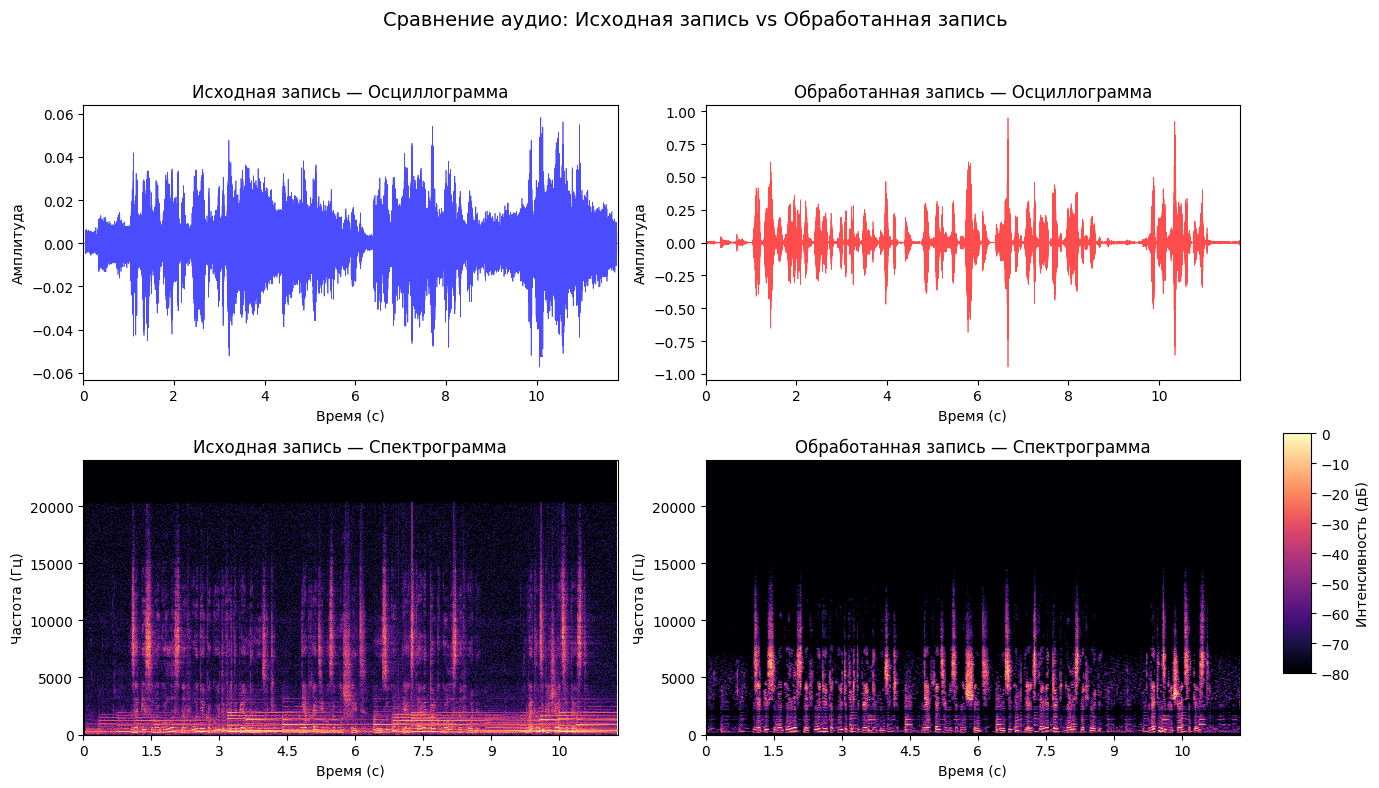

In [12]:
original_file = "Recording.mp3"
processed_file = "second_try.wav"

plot_audio_comparison(original_file, processed_file, sr=48000)

**ВЫВОД:**

Для фильтрации аудиозаписи было выбрано совмещение методов каскадной медианной фильтрации и SVD (Singular Value Decomposition).

Первый метод разделяет входящий сигнал на гармоническую и ударную части, где гармонической частью является фоновая музыка с гладким спектром, а ударной частью с резкими изменениями — речь, ударные инструменты и прочий шум. Второй метод раскладывает спектрограмму уже подчищенного звука на сумму сингулярных векторов. Шум и музыка должны соответствовать малым значениям в диагональной матрице, а речь — сильным. Выявленные шум и фоновая музыка умножаются на очень маленький коэффициент, чтобы заглушить их, минимально затронув голос.



---



Метод SVD должен работать хорошо для фильтрации *стационарного* шума, однако на *нестационарном* шуме (мелодия без явного повторения мотивов) он показывает себя плохо. Голос на итоговой записи стал громче, однако появились шумы из-за попыток сильного подавления музыки (малый коэффициент softness, подавление 95% шума и выше вызывает «металлический» звук у голоса) и музыка, хоть и стала тише, но не была заглушена целиком.